사용 디바이스: xpu


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

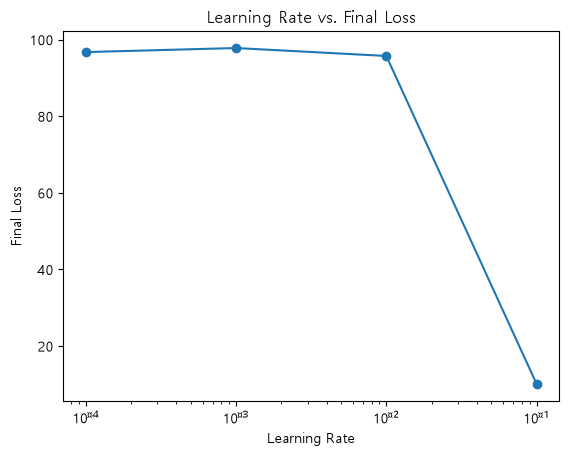

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from matplotlib import rc
rc('font', family='Malgun Gothic')

# 1 모델 정의
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        # 2차원 이미지 데이터를 1차원 벡터로 평탄화(flatten)
        x = x.view(-1, 28*28)   # -1 : 배치 크기 자동 계산
        return self.fc(x)

# 2 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307, ), (0.3081,)) # MNIST 평균 및 표준 편차
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()

# xpu 사용
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("사용 디바이스:", device)

# 평가 함수
def evaluate(model, data_loader, device):
    model.eval()    # 평가 모드로 전환
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

# 
learning_rates = [0.1, 0.01, 0.001, 0.0001]
final_losses = []

for lr in learning_rates:
    model = SimpleMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(10):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)  # 입력 데이터를 xpu로 이동
            labels = labels.to(device)  # 정답 데이터를 xpu로 이동

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    # 테스트 데이터셋을 이용하여 모델 평가 (평균 손실 기록)
    loss_avg = evaluate(model, test_loader, device)
    final_losses.append(loss_avg)

plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Learning Rate vs. Final Loss")
plt.xscale('log')
plt.show()

사용 디바이스: xpu


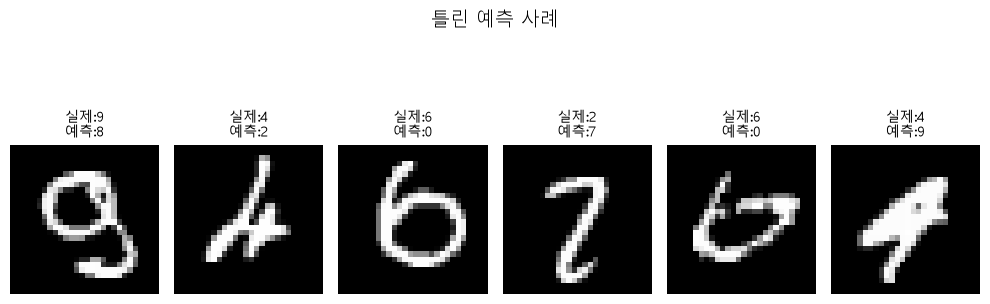

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', family='Malgun Gothic')

# 모델 정의
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 128),  nn.ReLU(),  nn.Dropout(0.2),
            nn.Linear(128, 64),     nn.ReLU(),  nn.Dropout(0.2),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.network(self.flatten(x))
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train = datasets.MNIST('./data', train=True, download=True, transform=transform)
test = datasets.MNIST('./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=1000, shuffle=False)

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print("사용 디바이스:", device)

# 학습
Model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses = []
model.train()
for _ in range(5):
    running = 0.0
    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        out = model(data)
        loss = criterion(out, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()
    train_losses.append(running / len(train_loader))


# 틀린 예측 수집
wrong_images, wrong_preds, wrong_targets = [], [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        out = model(data)
        preds = out.argmax(dim=1)
        mask = preds != target
        idxs = mask.nonzero().squeeze()
        for i in idxs:
            if len(wrong_images) >= 6: break
            wrong_images.append(data[i])
            wrong_preds.append(preds[i].item())
            wrong_targets.append(target[i].item())
    # 한 번에 6개 모이면 중단
    if len(wrong_images) >= 6:
        pass

wrong_images = torch.stack(wrong_images).detach().cpu()

plt.figure(figsize=(10,4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1,6,i+1)
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'실제:{wrong_targets[i]}\n예측:{wrong_preds[i]}', fontsize=10)
plt.suptitle("틀린 예측 사례", fontsize=14)
plt.tight_layout()
plt.show()

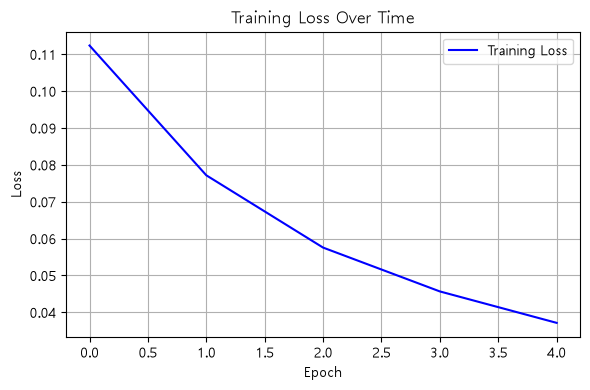

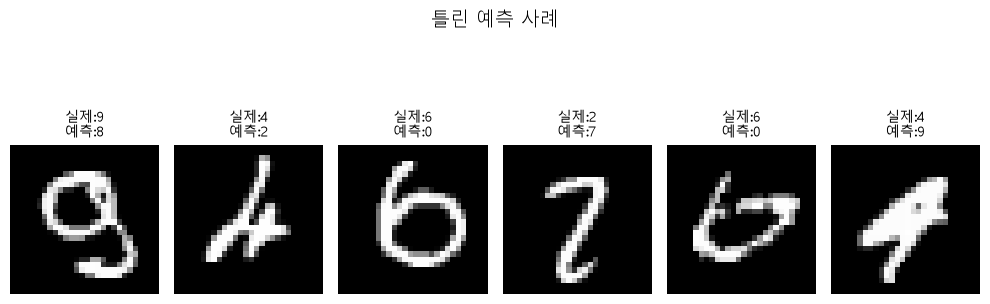

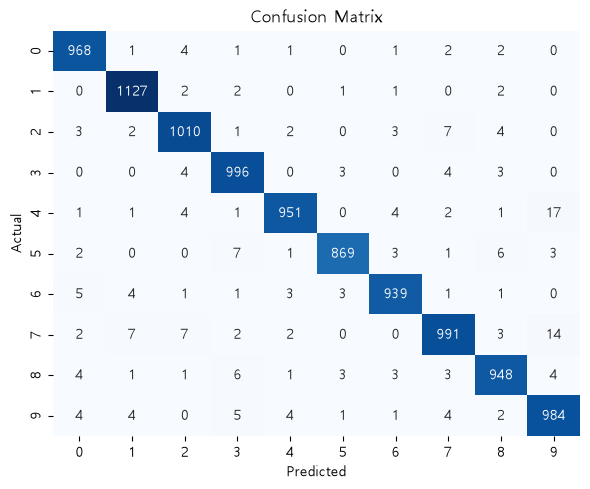

In [3]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# (1) 손실 곡선
plt.figure(figsize=(6,4))
plt.plot(train_losses, 'b-', label='Training Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

# (2) 틀린 예측
plt.figure(figsize=(10,4))
for i in range(len(wrong_images)):
    ax = plt.subplot(1,6,i+1)
    ax.imshow(wrong_images[i].squeeze(), cmap='gray')
    ax.axis('off')
    ax.set_title(f'실제:{wrong_targets[i]}\n예측:{wrong_preds[i]}', fontsize=10)
plt.suptitle("틀린 예측 사례", fontsize=14)
plt.tight_layout()
plt.show()

# (3) 혼동 행렬
# 전체 예측값/실제값 수집
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        out = model(data)
        all_preds.extend(out.argmax(dim=1).tolist())
        all_labels.extend(target.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()